Dataset Loaded ✅
     NAME  AGE     CITY COURSE  SLEEP HOURS
0  SHREYA   21   KANPUR    BCA            7
1   TEJAS   20   KANPUR  B.COM            8
2     SIA   23    DELHI    BBA            6
3   AARAV   19  GURGAON    LLB            9
4  ADITYA   24  UDAIPUR     BA            8

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         5 non-null      object
 1   AGE          5 non-null      int64 
 2   CITY         5 non-null      object
 3   COURSE       5 non-null      object
 4   SLEEP HOURS  5 non-null      int64 
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None

Missing Values:
NAME           0
AGE            0
CITY           0
COURSE         0
SLEEP HOURS    0
dtype: int64

After Encoding:
   NAME  AGE  CITY  COURSE  SLEEP HOURS
0     2   21     2       3            7
1     4   20     2       0            8
2    

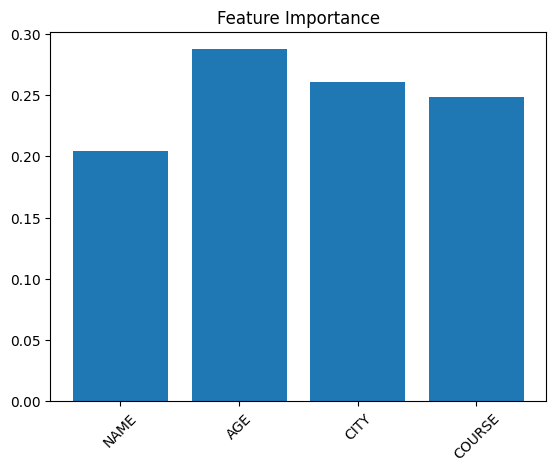

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# ==============================
# 1️⃣ LOAD DATA
# ==============================

# If CSV:
# df = pd.read_csv("data.csv")

# If Excel:
df = pd.read_excel("Student_performance_dataset.csv")

print("Dataset Loaded ✅")
print(df.head())

# ==============================
# 2️⃣ BASIC INFO
# ==============================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ==============================
# 3️⃣ HANDLE MISSING VALUES
# ==============================

df = df.fillna(df.mean(numeric_only=True))

# ==============================
# 4️⃣ ENCODE CATEGORICAL DATA
# ==============================

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.head())

# ==============================
# 5️⃣ SPLIT FEATURES & TARGET
# ==============================

# Assume last column = target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# ==============================
# 6️⃣ TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7️⃣ TRAIN MODEL
# ==============================

model = RandomForestClassifier()
model.fit(X_train, y_train)

# ==============================
# 8️⃣ PREDICTION
# ==============================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}% 🎯")

# ==============================
# 9️⃣ FEATURE IMPORTANCE
# ==============================

importances = model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()